Let us denote by $\sigma$ the sigmoid function $\sigma: (-\infty, \infty) \rightarrow (0, 1)$, given by formula
\begin{equation}
  \sigma(z) = \frac{1}{1 + e^{-z}},
\end{equation}
and let us assume that $y_j \in \{0, 1\}$, $j = 1, \dots, n$, are the binary labels.

The binary cross-entropy loss is then defined as
\begin{equation}
  L(y, z) = -y\log \sigma(z) - (1 - y) \log (1 - \sigma(z)).
\end{equation}

We will explore the difference between optimization problems for adding a new constant predictor $\hat \lambda$ in the forward stagewise procedure to an already existing predictior from a previous stage $f_{m - 1}(x_i)$ and estimating with a constant value $\hat \lambda$ from scratch.

## Derivation and Analysis

###Scenario A

Derive explicicitly the optimal $\hat \lambda$ by solving
\begin{equation}
  \hat\lambda = \mathrm{argmin}_\lambda \sum_{j = 1}^n L(y_j, \lambda).
\end{equation}

We are taking derivative of the function above with respect to $\lambda$
\begin{align}
  \partial_\lambda \sum_{j = 1}^n L(y_j, \lambda)
  &= \sum_{j = 1}^n \partial_\lambda L(y_j, \lambda)\\
  &= \sum_{j = 1}^n \big[ -\frac{y_j}{\sigma(\lambda)} \partial_\lambda \sigma(\lambda) - \frac{1 - y_j}{\sigma(\lambda) - 1}\partial_\lambda \sigma(\lambda)\big]\\
  &= \sum_{j = 1}^n \big[\sigma(\lambda)(1 - \sigma(\lambda))\big(\frac{y_j(\sigma(\lambda) - 1) + \sigma(\lambda)(1 - y_j)}{\sigma(\lambda)(1 - \sigma(\lambda))} \big)\big]\\
  &= \sum_{j = 1}^n[\sigma(\lambda) - y_j].
\end{align}

We can see that $\partial_\lambda \Sigma_{j = 1}^n L(y_j, \lambda) = 0$ iff $\sigma(\lambda) = \overline Y$. Let us assume that $0 < \overline Y < 1$. By inversing the sigmoid function we obtain that it is equivalent to
\begin{equation}
  \lambda = \log \big(\frac{\overline Y}{1 - \overline Y}\big).
\end{equation}

As $\lambda \rightarrow -\infty$ we get that $\sigma(\lambda) \rightarrow 0$ and $L(y_j, \lambda) \rightarrow \infty$ if $y_j = 1$.

As $\lambda \rightarrow \infty$ we get that $\sigma(\lambda) \rightarrow 1$ and $L(y_j, \lambda) \rightarrow \infty$ if $y_j = 0$.

That means that in point where the derivative vanishes global minimum is attained i.e.
$$
  \hat \lambda = \log \big(\frac{\overline Y}{1 - \overline Y}\big).
$$

### Scenario B

Now assume we already have an existing predictor $f_i = f_{m = 1}(x_i)$ and wish to solve
\begin{equation}
  \hat \lambda = \mathrm{argmin}_\lambda \sum_{j = 1}^n L(y_j, f_j + \lambda).
\end{equation}

Using that $\lambda \rightarrow f_j + \lambda$ is an affinic transform we get
\begin{equation}
  \partial_\lambda \sum_{j = 1}^nL(y_j, f_j + \lambda) = \sum_{j = 1}^n[\sigma(f_j + \lambda) - y_j] = 0
\end{equation}
iff
\begin{equation}
  \sum_{j = 1}^n \big[\frac{1}{1 + e^{-f_j}e^{-\lambda}}\big] = n \overline Y.
\end{equation}

In contrast to first scenario, this equation does not admit a closed-form solution for $\lambda$. Indeed, $\lambda$ appears inside a nonlinear expression under the summation, and each term involves a possibly different constant factor $e^{-f_j}$.

The boundary behavior remains analogous. Provided that $0 < \overline{Y} < 1$, as $\lambda \rightarrow \pm \infty$, we have
\begin{equation}
  \sum_{j = 1}^n L(y_j, f_j + \lambda) \rightarrow \infty.
\end{equation}
In this case the solution is attained at a finite value of $\lambda$ in which the derivative vanishes.

Function
\begin{equation}
  \lambda \mapsto \frac{1}{1 + e^{-f_j} e^{-\lambda}} = \sigma(f_j + \lambda)
\end{equation}
is smooth on $(-\infty, \infty)$.

Consequently,
\begin{align}
  \partial^2_{\lambda\lambda} \sum_{j = 1}^n L(y_j, f_j + \lambda)
  &= \sum_{j = 1}^n \partial^2_{\lambda\lambda}L(y_j, f_j + \lambda)\\
  & = \sum_{j = 1}^n \sigma(\lambda + f_j)(1 - \sigma(\lambda + f_j))\\
  &> 0.
\end{align}

Since both the first and second derivatives exist and the second derivative is strictly positive in $(-\infty, \infty)$, we can use standard numerical optimization methods, e.g. Newton's method or gradient-based solvers, to efficiently find the optimal value of $\lambda$.

## Loss Landscape Exploration

### Binary cross-entropy loss function formula for numerical applications

\begin{align}
  L(y, z)
  &= -y\log \sigma(z) - (1 - y) \log (1 - \sigma(z))\\
  &= -y\log \big(\frac{1}{1 + e^{-z}}\big) - (1 - y) \log (\frac{e^{-z}}{1 + e^{-z}})\\
  &= (1-y)z - \log\big(\frac{1}{1 + e^{-z}}\big)\\
  &= \log (1 + e^z) - y z.
\end{align}

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12107/4191322401.py:40: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(lambda_grid, loss_A, label="Scenario A: L(y, $\lambda$)")
/tmp/ipykernel_12107/4191322401.py:41: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(lambda_grid, loss_B, label="Scenario B: L(y, $f_i + \lambda$)")
/tmp/ipykernel_12107/4191322401.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")
/tmp/ipykernel_12107/4191322401.py:47: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Loss as a Function of $\lambda$")


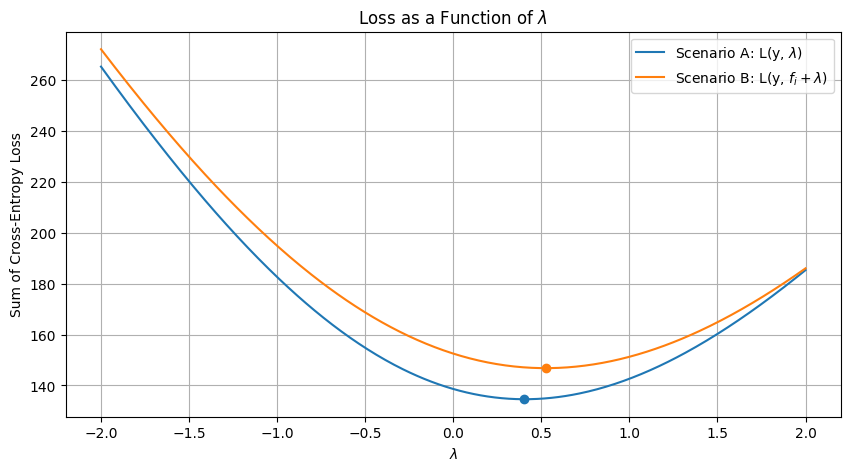

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

n = 200
k = 80
m = n - k
mean_y = k/n

y = np.concatenate((np.zeros(k, dtype=int), np.ones(m, dtype=int)))
np.random.seed(42)
f = np.random.normal(0, 1, size=n)

def cross_entropy_loss_sum(y, lambdas, f=None):
  lambdas = lambdas[:, None]
  if f is None:
    z = lambdas
  else:
    z = f + lambdas
  return np.sum(np.log(1 + np.exp(z))  - y * z, axis=1)

lambda_grid = np.linspace(-2, 2, 400)

loss_A = cross_entropy_loss_sum(y, lambda_grid)
loss_B = cross_entropy_loss_sum(y, lambda_grid, f)

def objective(_lambda):
  return np.sum(np.log(1 + np.exp(f + _lambda))  - y * (f + _lambda))

def grad_fun(_lambda):
  return np.sum(1/(1 + np.exp(-(f + _lambda))) - y)

fit_A = cross_entropy_loss_sum(y, np.array((mean_y,)))[0]
res = minimize(objective, x0=0.0, jac=grad_fun, method="BFGS")
fit_B = res.fun

# Plotting
plt.figure(figsize=(10, 5))

plt.plot(lambda_grid, loss_A, label="Scenario A: L(y, $\lambda$)")
plt.plot(lambda_grid, loss_B, label="Scenario B: L(y, $f_i + \lambda$)")
plt.scatter(mean_y, fit_A)
plt.scatter(res.x[0], fit_B)

plt.xlabel("$\lambda$")
plt.ylabel("Sum of Cross-Entropy Loss")
plt.title("Loss as a Function of $\lambda$")
plt.legend()
plt.grid(True)

plt.show()
